# CH7. 군집화
###05. DBSCAN

밀도 기반 군집화의 대표적인 알고리즘이다. DBSCAN은 간단하고 직관적인 알고리즘으로 되어있음에도 데이터의 분포가 기하학적으로 복잡한 데이터 세트에도 효과적인 군집화가 가능하다.

내부의 원 모양과 외부의 원 모양 형태의 분포를 가진 데이터 세트를 군집화한다고 가정할 때 K-평균, 평균 이동, GMM으로는 효과적인 군집화를 수행하기 어렵다.

DBSCAN은 특정 공간 내에 데이터 밀도 차이를 기반 알고리즘으로 하고 있어서 복잡한 기하학적 분포도를 가진 데이터 세트에 대해서도 군집화를 잘 수행한다.


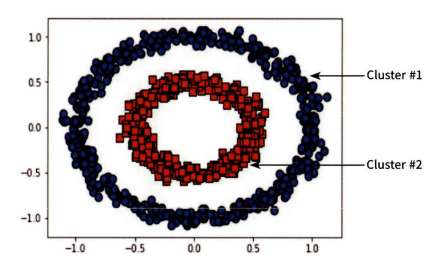

**DBSCAN을 구성하는 가장 중요한 두 가지 파라미터**
- $epsilon$: 입실론 주변 영역 [개별 데이터를 중심으로 입실론 반경을 가지는 원형의 영역]
- $최소 데이터 개수$: 개별 데이터의 입실론 주변 영역에 포함되는 타 데이터의 개수

- 핵심 포인트: 주변 영역 내에 최소 데이터 개수 이상의 타 데이터를 가지고 있을 경우 해당 데이터
- 이웃 포인트: 주변 영영 내에 위치한 타 데이터
- 경계 포인트: 주변 영역 내에 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않지만 핵심 포인트를 이웃 포인트로 가지고 있는 데이터
- 잡음 포인트: 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않으며, 핵심 포인트도 이웃 포인트로 가지고 있지 않는 데이터

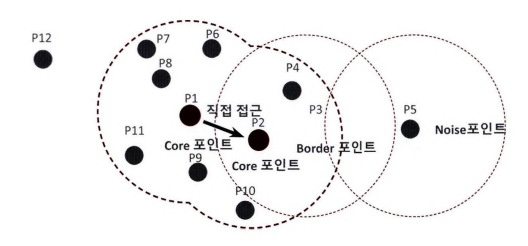

$eps$: 입실론 주변 영역의 반경

```min_samples```:핵심 포인트가 되기 위해 입실론 주변 영역 내에 포함되어야 할 데이터의 최소 개수를 의미한다.

### DBSCAN 적용하기 - 붓꽃 데이터 세트

In [3]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the iris dataset
iris = load_iris()
# Create a DataFrame for iris data
irisDF = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [4]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


- dbscan_cluster

:0과 1외에 -1이 군집 레이블로 있는 것을 알 수 있다. 군집레이블이 -1인 것은 노이즈에 속하는 군집을 의미한다.

target값의 유형이 3가지인데 군집이 2개가 되었다고 군집화 효율이 떨어진다는 의미는 아니다. DBSCAN은 군집의 개수를 알고리즘에 따라 자동으로 지정하므로 DBSCAN에서 군집의 개수를 지정하는 것은 무의미하다.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline


def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
  if dataframe is None:
    print("Error: DataFrame is required.")
    return

  unique_labels = np.unique(dataframe[label_name])
  markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

  for label in unique_labels:
    label_cluster = dataframe[dataframe[label_name] == label]

    # Ensure 'ftr1' and 'ftr2' exist before plotting
    if 'ftr1' in label_cluster.columns and 'ftr2' in label_cluster.columns:
      plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
      marker=markers[label % len(markers)])

    if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
      # Assuming cluster_result has a .cluster_centers_ attribute
      center_x_y = cluster_result.cluster_centers_[label]

      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
      marker=markers[label % len(markers)])
      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
      marker='$%d$' % label)

  plt.show()

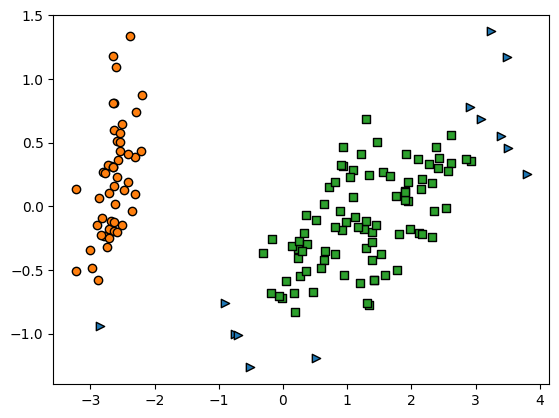

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# Define the visualize_cluster_plot function here to ensure it's available
def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
  if dataframe is None:
    print("Error: DataFrame is required.")
    return

  unique_labels = np.unique(dataframe[label_name])
  markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

  for label in unique_labels:
    label_cluster = dataframe[dataframe[label_name] == label]

    # Ensure 'ftr1' and 'ftr2' exist before plotting
    if 'ftr1' in label_cluster.columns and 'ftr2' in label_cluster.columns:
      plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
      marker=markers[label % len(markers)])

    if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
      # Assuming cluster_result has a .cluster_centers_ attribute
      center_x_y = cluster_result.cluster_centers_[label]

      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
      marker=markers[label % len(markers)])
      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
      marker='$%d$' % label)

  plt.show()

#2차원으로 시각화하기 위해 PCA n_components=2로 피처 데이터 세트 변환
pca = PCA(n_components=2, random_state=0)
pca_transformed = pca.fit_transform(iris.data)
#visualize_cluster_plot() 함수는 ftr1, ftr2칼럼을 좌표에 표현하므로 PCA 변환값을 해당 칼럼으로 생성
irisDF['ftr1'] = pca_transformed[:,0]
irisDF['ftr2'] = pca_transformed[:,1]

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


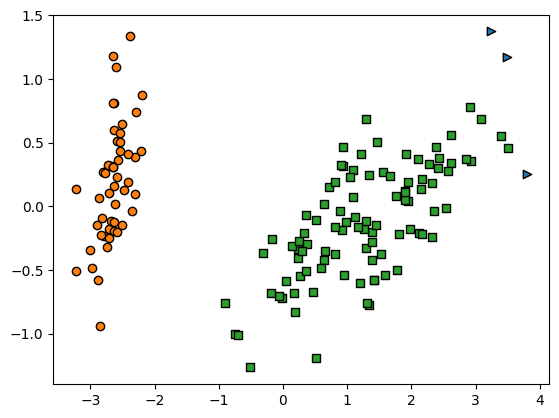

In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

In [11]:
dbscan = DBSCAN(eps=0.6, min_samples=16, metric='euclidean')

### DBSCAN 적용하기 - make_circles() 데이터 세트

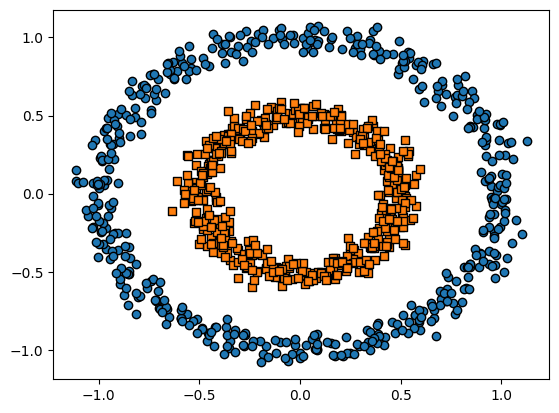

In [14]:
from sklearn.datasets import make_hastie_10_2, make_circles

X, y = make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data=X, columns=['ftr1','ftr2'])
clusterDF['target']=y

visualize_cluster_plot(None, clusterDF,'target', iscenter=False)

- K-평균으로 군집화

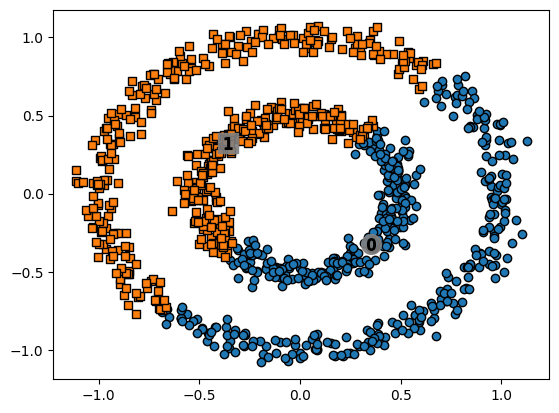

In [16]:
#KMeans로 make_circles() 데이터 세트를 군집화 수행
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels = kmeans.fit_predict(X)
clusterDF['kmeans_cluster'] = kmeans_labels

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_cluster', iscenter=True)

-  GMM 군집화

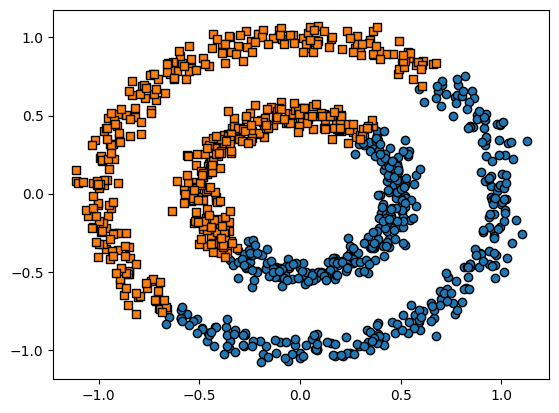

In [17]:
#GMM으로 make_circles() 데이터 세트를 군집화 수행
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=0)
gmm_label = gmm.fit(X).predict(X)
clusterDF['gmm_cluster'] = gmm_label

visualize_cluster_plot(gmm, clusterDF, 'gmm_cluster', iscenter=False)

- DBSCAN으로 군집화

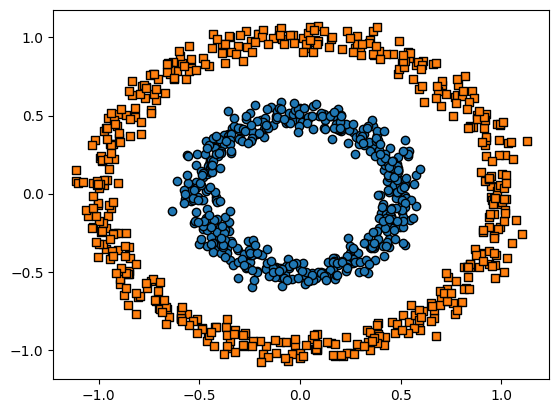

In [18]:
#DBSCAN으로 make_circles()데이터 세트 군집화 수행
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterDF['dbscan_cluster'] = dbscan_labels

visualize_cluster_plot(dbscan, clusterDF, 'dbscan_cluster', iscenter=False)

### 06. 군집화 실습 - 고객 세그먼테이션

고객 세그먼테이션은 CRM이나 마케팅의 중요 기반 요소이다.


고객 분류가 사용되는 대부분의 비즈니스가 상품 판매에 중점을 두고 있기 때문에 더 중요한 분류 요소는 어떤 상품을 얼마나 많은 비용을 써서 얼마나 자주 사용하는가에 기반한 정보로 분류하는 것이 보통이다.

고객의 어떤 요소를 기반으로 군집화할 것인가를 결정하는 것이 중요하다. 여기서는 기본적인 고객 분석 요소인 RFM기법을 이용하겠다 . RFM기법은 Recency(R), Frequency(F), Monetary Value(M)의 각 앞글자를 합한 것으로서 각 단어의 의미는 다음과 같다.

- RECENCY: 가장 최근 상품 구입 일에서 오늘까지의 기간
- FREQUENCY: 상품 구매 횟수
- MONETARY: 총 구매 금액

**데이터 세트 로딩과 데이터 클렌징**

In [4]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

retail_df = pd.read_excel(io='/content/drive/MyDrive/data/Online Retail.xlsx')
retail_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [5]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
retail_df = retail_df[retail_df['Quantity']>0]
retail_df = retail_df[retail_df['UnitPrice']>0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]
print(retail_df.shape)
retail_df.isnull().sum()

(397884, 8)


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [7]:
retail_df['Country'].value_counts()[:5]

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484


In [8]:
retail_df = retail_df[retail_df['Country']=='United Kingdom']
print(retail_df.shape)

(354321, 8)


**RFM 기반 데이터 가공**

먼저 UnitPrice와 Quantity를 곱해 주문 금액 데이터 생성

CustomerNo도 편리한 식별성을 위해 float형을 int형으로 변경

In [9]:
retail_df['sale_amount'] = retail_df['Quantity']*retail_df['UnitPrice']
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

In [19]:
print(retail_df['CustomerID'].value_counts().head(5))
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)[:5])

CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: count, dtype: int64
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


몇 특정 고객이 많은 주문 건수와 주문 금액을 가지고 있다. 주어진 온라인 판매 데이터 세트는 전형적인 판매 데이터 세트와 같이 주문번호+ 상품코드 레벨의 식별자로 되어 있다.

InvoiceNo + StockCode로 Groupby를 수행하면 거의 1에 가깝게 유일한 식별자 레벨이 된다.

In [11]:
retail_df.groupby(['InvoiceNo', 'StockCode'])['InvoiceNo'].count().mean()

np.float64(1.028702077315023)

지금 수행하는 RFM 기반 고객 세그멘테이션은 고객 레벨로 주문기간, 주문횟수, 주문금액 데이터를 기반으로 해 세그멘테이션을 수행하는 것이다. 이에 주문번호+상품코드 기준의 데이터를 고객 기준의 Recency, Frequency, Monetary value 데이터로 변경하겠다. 이를 위해서는 주문번호 기준의 데이터를 개별 고객 기준의 데이터로 Group by 해야 한다.

In [16]:
# DataFrame의 groupby()의 multiplt연산을 위해 agg() 이용
# Recency는 InvoiceDate칼럼의 max()에서 데이터 가공
# Frequency는 InvoiceNo칼럼의 count(), Monetary value는 sale_amount칼럼의 sum()

aggregations = {
    'InvoiceDate': 'max',
    'InvoiceNo': 'count',
    'sale_amount': 'sum'
}
cust_df = retail_df.groupby('CustomerID').agg(aggregations)
#groupby된 결과 칼럼 값을 Recency, Frequency, Monetary로 변경
cust_df = cust_df.rename(columns={'InvoiceDate':'Recency',
                                  'InvoiceNo':'Frequency',
                                  'sale_amount':'Monetary'})

cust_df = cust_df.reset_index()
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4595,33719.73


In [22]:
import datetime as dt

cust_df['Recency'] = dt.datetime(2011, 12, 10) - cust_df['Recency']
cust_df['Recency'] = cust_df['Recency'].apply(lambda x:x.days+1)
print('cust_df로우와 칼럼 건수는', cust_df.shape)
cust_df.head(3)

cust_df로우와 칼럼 건수는 (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,3,103,4196.01
2,12748,1,4595,33719.73


**RFM 기반 고객 세그멘테이션**

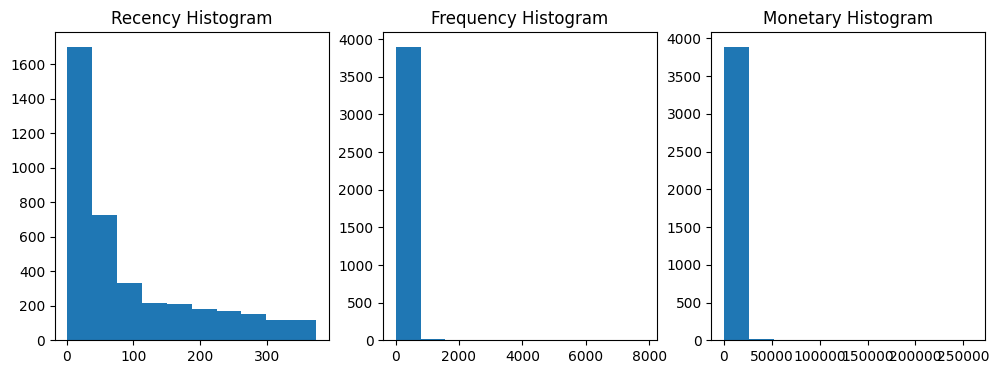

In [23]:
fig,(ax1, ax2, ax3) = plt.subplots(figsize=(12,4), nrows=1, ncols=3)
ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])

ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])

ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])

plt.show()

In [24]:
cust_df[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.742092,90.388010,1864.385601
std,99.533485,217.808385,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,300.280000
50%,51.000000,41.000000,652.280000
75%,143.000000,99.250000,1576.585000
max,374.000000,7847.000000,259657.300000


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

X_features = cust_df[['Recency','Frequency','Monetary']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어는: {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는: 0.576


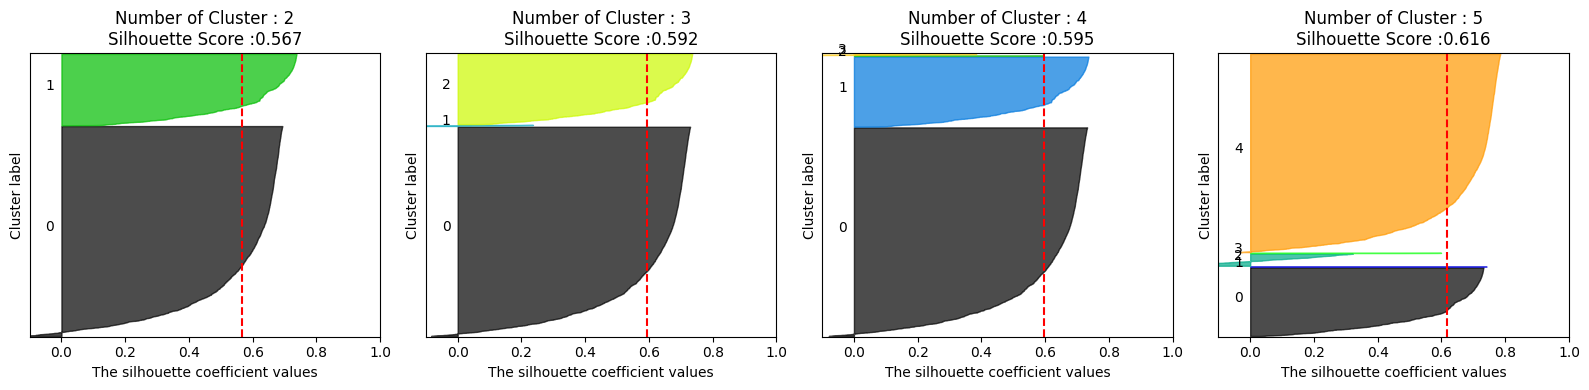

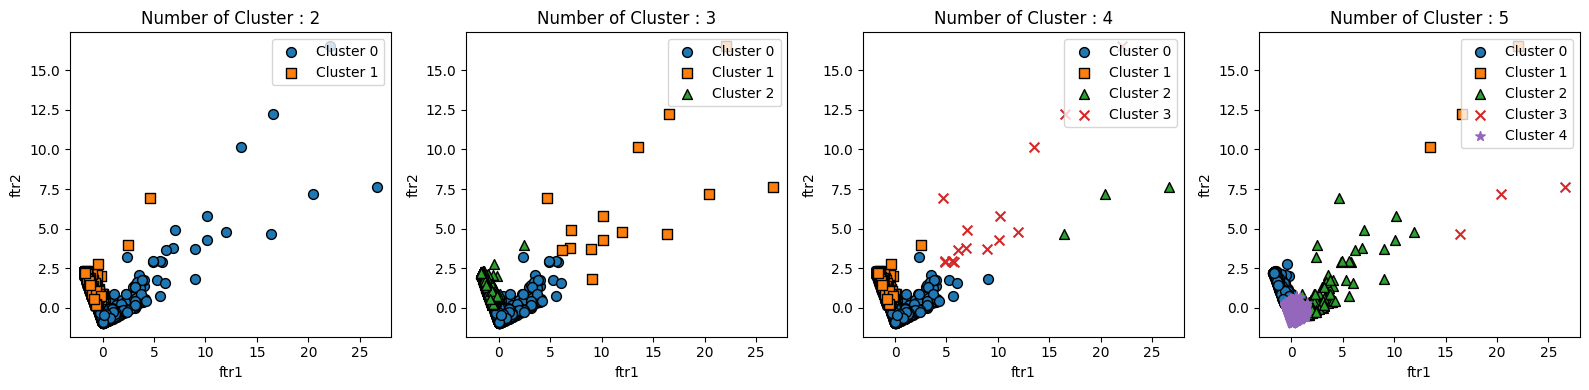

In [37]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

def visualize_silhouette(cluster_lists, X_features):
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init=10)
        cluster_labels = kmeans.fit_predict(X_features)

        silhouette_avg = silhouette_score(X_features, cluster_labels)
        sample_silhouette_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : ' + str(n_cluster) + '\n' + 'Silhouette Score :' + str(round(silhouette_avg, 3)))
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i
            color = cm.nipy_spectral(float(i) / n_cluster)

            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=silhouette_avg, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()

def visualize_kmeans_plot_multi(cluster_lists, X_features, iscenter=False):
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

    pca = PCA(n_components=2, random_state=0)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(data=pca_transformed, columns=['ftr1', 'ftr2'])

    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init=10)
        cluster_labels = kmeans.fit_predict(X_features)
        dataframe['cluster'] = cluster_labels
        unique_labels = np.unique(dataframe['cluster'])

        for label in unique_labels:
            label_cluster = dataframe[dataframe['cluster'] == label]
            marker = markers[label % len(markers)]

            if marker in ['x', '+', '*']:
                axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'],
                                 marker=marker, label=f'Cluster {label}', s=50)
            else:
                axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                                 marker=marker, label=f'Cluster {label}', s=50)

        if iscenter and hasattr(kmeans, 'cluster_centers_'):
            center_x_y = pca.transform(kmeans.cluster_centers_)
            for label, center in enumerate(center_x_y):
                axs[ind].scatter(x=center[0], y=center[1], s=200, color='gray', alpha=0.9,
                                 marker=markers[label % len(markers)])
                axs[ind].scatter(x=center[0], y=center[1], s=70, color='k', edgecolor='k',
                                 marker='$%d$' % label)

        axs[ind].set_title('Number of Cluster : ' + str(n_cluster))
        axs[ind].set_xlabel('ftr1')
        axs[ind].set_ylabel('ftr2')

        axs[ind].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

visualize_silhouette([2, 3, 4, 5], X_features_scaled)
visualize_kmeans_plot_multi([2, 3, 4, 5], X_features_scaled)

군집이 3개 이상일 때부터는 데이터 세트의 개수가 너무 작은 군집이 만들어진다.

- 군집이 3개일 경우: 0번 군집의 데이터 건수가 매우 작다.
- 군집 4개: 2번, 3번 군집의 데이터 수가 적다.
- 군집 5개: 2,3,4 군집의 데이터 세트의 개수가 적다.

특이한 데이터 세트를 분리하고 도출하는 것이 군집화의 목표이기도 하나 크게 왜곡된 데이터 세트의 도출은 굳이 군집화를 이용하지 않고도 간단한 데이터 분석만으로도 충분히 가능하다.

지나치게 왜곡된 데이터 세트는 K-평균과 같은 거리 기반의 군집화 알고리즘에서 지나치게 일반적인 군집화 결과를 도출하게 된다.

비지도 학습의 알고리즘의 하나인 군집화의 기능적 의미는 **숨어있는 새로운 집단을 발견**하는 것이다.
새로운 군집 내의 데이터 값을 분석하고 이해함으로써 이 집단에 새로운 의미를 부여할 수 있다. 이를 통해 전체 데이터를 다른 각도로 바라볼 수 있게 한다.

데이터 세트의 **왜곡 정도는 낮추기 위해** 가장 자주 사용되는 방법은 데이터 값에 **로그**를 적용하는 로그 변환이다.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

#Recency, Frequency, Monetary 칼럼에 np.log1p()로 Log Transformation
cust_df['Recency_log'] = np.log1p(cust_df['Recency'])
cust_df['Frequency_log'] = np.log1p(cust_df['Frequency'])
cust_df['Monetary_log'] = np.log1p(cust_df['Monetary'])

#Log Transformation 데이터에 StardardScaler 적용
X_features = cust_df[['Recency_log', 'Frequency_log', 'Monetary_log']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3,random_state=0)
labels = kmeans.fit_predict(X_features_scaled)

cust_df['cluster_label'] = labels

print('실루엣 스코어는: {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는: 0.303


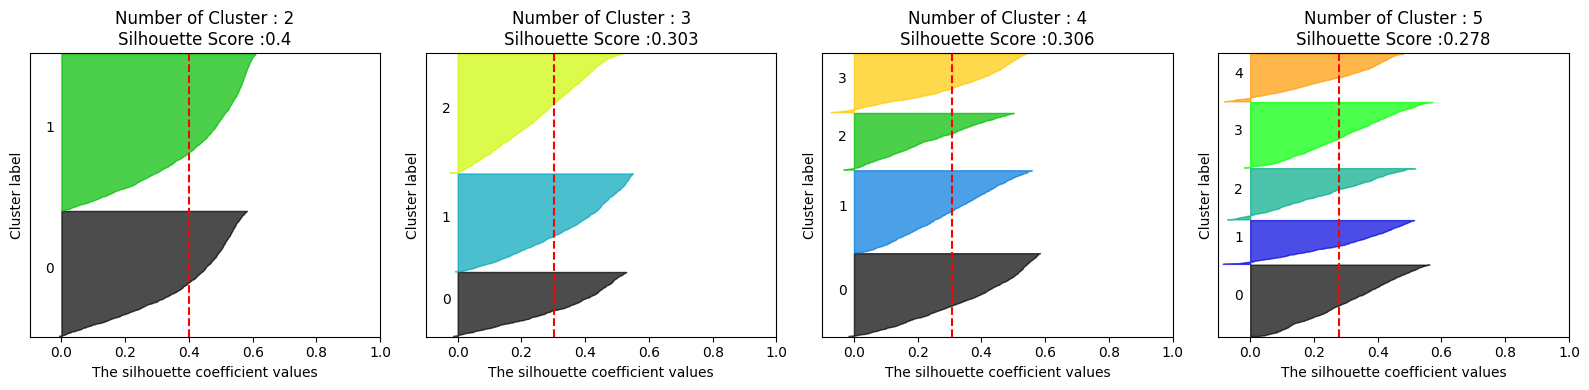

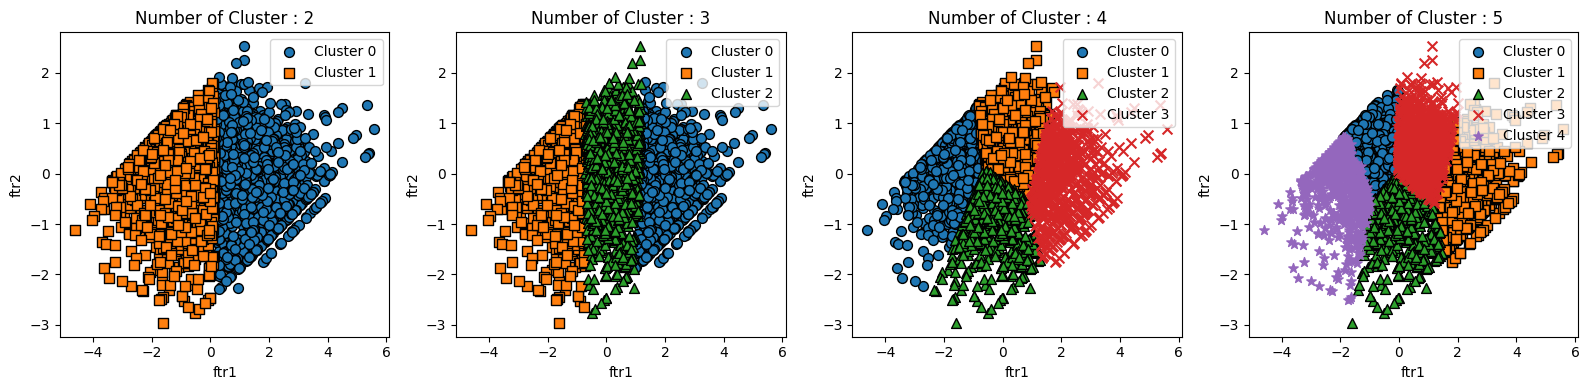

In [40]:
visualize_silhouette([2, 3, 4, 5], X_features_scaled)
visualize_kmeans_plot_multi([2, 3, 4, 5], X_features_scaled)

실루엣 스코어는 로그 변환하기 전보다 떨어진다. 하지만 실루엣 스코어의 절대치가 중요한 것이 아니다. 어떻게 개별 군집이 더 균일하게 나뉠 수 있는지가 더 중요하다.

###07. 정리

1. K-평균: 거리 기반으로 군집 중심점을 이동시키면서 군집화를 수행한다. **쉽고 직관적이지만 복잡한 구조를 가지는 데이터 세트에 적용하기에 한계**가 있다. K-평균은 군집이 잘 되었는지 평가하기 위해 **실루엣 계수**를 사용한다.

2. 평균 이동: 거리 중심이 아닌 데이터가 모여 있는 밀도가 가장 높은 쪽으로 군집 중심점을 이동하며 군집화한다. **컴퓨터 비전이나 이미지, 영상 데이터에서 특정 개체를 구분하거나 움직임을 추적**하는 데 뛰어난 역할을 한다.

3. GMM: 데이터가 여러 개의 **가우시안**분포를 모델에 섞어서 생성된 모델로 가정해 수행하는 방식이다. 전체 데이터 세트에서 서로 다른 정규 분포 형태를 추출해 다른 정규 분포를 가진 데이터 세트를 각각 군집화하는 것이다. **유연하게 적용되지만 수행시간이 오래 걸린다.**

4. DBSCAN: 밀도 기반 군집화이다. 입실론 주변 영역 내에 포함되는 최소 데이터 개수의 충족 여부에 따라 핵심, 이웃, 경계, 잡음 포인트로 구분하고 특정 핵심 포인트에서 직접 접근이 가능한 다른 포인트를 서로 연결하며 군집화 진행. **간단하고 직관적이며 복잡한 데이터 세트에도 효과적**